In [1]:
# get figures and experiment results for showcasing
import gdown
url = "https://drive.google.com/drive/folders/1iC9IEsFO4k9uzKJmB6ExM7K8B0Wa-ozT?usp=drive_link"
gdown.download_folder(url, quiet=True)

['/content/convlab_rl_tutorial/convlab_paper_experiments/mwoz/experiment_2022-10-04-14-28-08/configs/config_saved.json',
 '/content/convlab_rl_tutorial/convlab_paper_experiments/mwoz/experiment_2022-10-04-14-28-08/logs/train_DEBUG.log',
 '/content/convlab_rl_tutorial/convlab_paper_experiments/mwoz/experiment_2022-10-04-14-28-08/logs/train_ERROR.log',
 '/content/convlab_rl_tutorial/convlab_paper_experiments/mwoz/experiment_2022-10-04-14-28-08/logs/train_INFO.log',
 '/content/convlab_rl_tutorial/convlab_paper_experiments/mwoz/experiment_2022-10-04-14-28-08/logs/train_WARNING.log',
 '/content/convlab_rl_tutorial/convlab_paper_experiments/mwoz/experiment_2022-10-04-14-28-08/TB_summary/events.out.tfevents.1664886488.hilbert314',
 '/content/convlab_rl_tutorial/convlab_paper_experiments/mwoz/experiment_2022-10-04-14-28-08/time.txt',
 '/content/convlab_rl_tutorial/convlab_paper_experiments/mwoz/experiment_2022-10-05-12-21-42/configs/config_saved.json',
 '/content/convlab_rl_tutorial/convlab_pa

In [2]:
# get ConvLab-3 repo
!git clone -b emnlp_demo https://github.com/ConvLab/ConvLab-3.git

Cloning into 'ConvLab-3'...
remote: Enumerating objects: 11191, done.
remote: Counting objects: 100% (1481/1481), done.
remote: Compressing objects: 100% (504/504), done.
remote: Total 11191 (delta 1019), reused 1387 (delta 970), pack-reused 9710
Receiving objects: 100% (11191/11191), 1.12 GiB | 32.89 MiB/s, done.
Resolving deltas: 100% (7795/7795), done.
Updating files: 100% (1219/1219), done.


In [3]:
import json
from IPython.display import display, Image

# Train and Evaluate Reinforcement Learning Policies

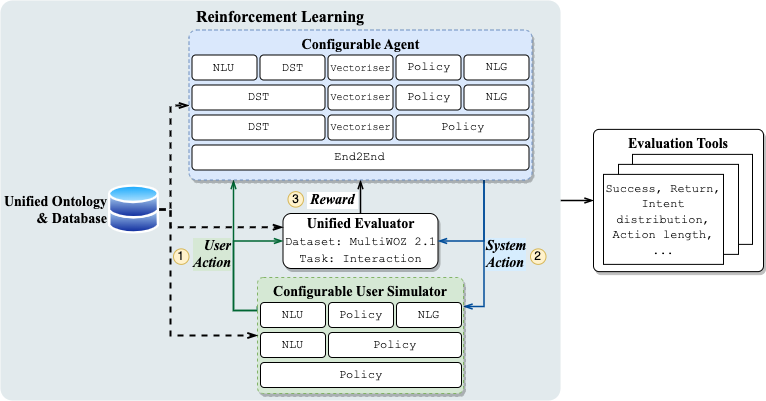

In [4]:
display(Image(filename='convlab_rl_tutorial/rl_figures/rl_overview.png'))

## 1. Specify Dialogue System Pipeline and User Environment



The dialogue system pipeline and user environment for RL training and evaluation is specified in a config file.

ConvLab-3 offers multiple config files that are easy to adapt.

In [5]:
!ls "ConvLab-3/convlab/policy/vtrace_DPT/configs"

emoUS-BertNLU-RuleDST-PPOPolicy.json	  multiwoz21_dpt.json
GenTUS-BertNLU-RuleDST-VtracePolicy.json  RuleUser-Semantic-RuleDST.json
GenTUS-Semantic-RuleDST.json		  RuleUser-TemplateNLG-SetSUMBT.json
GenTUS-SetSUMBT-SCGPT.json		  RuleUser-TemplateNLG-SetSUMBT-VectorUncertainty.json
GenTUS-SetSUMBT-TemplateNLG.json	  RuleUser-TemplateNLG-TripPy.json


In [7]:
config_dict = json.load(open("ConvLab-3/convlab/policy/vtrace_DPT/configs/GenTUS-SetSUMBT-SCGPT.json"))

print("*"*40 + "Dialogue System Agent" + "*"*40)
print("\n")
for key in config_dict:

    if key == "nlu_usr":
        print("*"*40 + "User Agent" + "*"*40)
        print("\n")

    print("-"*45 + f"{key}" + "-"*45)
    print(json.dumps(config_dict[key], indent=2))
    print("\n")

****************************************Dialogue System Agent****************************************


---------------------------------------------goals---------------------------------------------
{
  "single_domains": false,
  "allowed_domains": null
}


---------------------------------------------model---------------------------------------------
{
  "load_path": "from_pretrained",
  "use_pretrained_initialisation": false,
  "pretrained_load_path": "",
  "seed": 0,
  "process_num": 4,
  "eval_frequency": 1000,
  "num_eval_dialogues": 500,
  "process_num_train": 1,
  "total_dialogues": 10000,
  "update_rounds": 1,
  "new_dialogues": 2,
  "sys_semantic_to_usr": false
}


---------------------------------------------vectorizer_sys---------------------------------------------
{
  "VectorNodes": {
    "class_path": "convlab.policy.vector.vector_nodes.VectorNodes",
    "ini_params": {
      "use_masking": true,
      "manually_add_entity_names": true,
      "seed": 0,
      "dataset_na

## 2. Train a RL agent

``python convlab/policy/vtrace_DPT/train.py --config_name=RuleUser-Semantic-RuleDST``

### Experiment Output

In [8]:
!ls convlab_rl_tutorial/experiment_2022-08-10-09-05-08

configs  logs  TB_summary  time.txt


## 3. Evaluate a RL agent
``python convlab/policy/evaluate.py --model_name=DDPT
                                    --config_path=convlab/policy/vtrace_DPT/configs/RuleUser-Semantic-RuleDST.json
                                    --verbose``

In [9]:
f = open("convlab_rl_tutorial/evaluation_logs/2023-08-01_12:04:03.log", "r")
print(f.read())

Vectorizer: Data set used is multiwoz21
We filter state by active domains: True
Entropy weight: 0.01
Online-Offline-ratio: 0.2
Behaviour cloning weight: 0.1
Supervised weight: 0.0
Vectorizer: Data set used is multiwoz21
Embedding semantic descriptions: True
Embedded descriptions successfully. Size: torch.Size([338, 768])
Data set used for descriptions: multiwoz21
We use Roberta to embed actions.
Vectorizer: Data set used is multiwoz21
Embedding semantic descriptions: True
Embedded descriptions successfully. Size: torch.Size([338, 768])
Data set used for descriptions: multiwoz21
We use Roberta to embed actions.
Initialised critic. Independent: True
Uncertainty threshold not set.
nlu info_dict is not initialized
dst info_dict is not initialized
policy info_dict is not initialized
nlg info_dict is not initialized
nlu info_dict is not initialized
dst info_dict is not initialized
nlg info_dict is not initialized
We check booking constraints: True
create goals from goal_generator...
NEW EPIS

# Compare different RL algorithms

In [10]:
!ls convlab_rl_tutorial/convlab_paper_experiments

mwoz  scratch  sgd


In [11]:
!ls convlab_rl_tutorial/convlab_paper_experiments/sgd

seed0  seed1  seed2


In [13]:
map_file = json.load(open("ConvLab-3/convlab/policy/plot_results/example_map.json"))
print(json.dumps(map_file, indent=2))

[
  {
    "dir": "scratch",
    "legend": "scratch"
  },
  {
    "dir": "sgd",
    "legend": "SGD"
  },
  {
    "dir": "mwoz",
    "legend": "1%MWOZ"
  }
]



``python convlab/policy/plot_results/plot.py --dir=convlab_paper_experiments/
                                              --map-file=convlab/policy/plot_results/example_map.json
                                              --out-file=convlab_paper_experiments/``

In [14]:
!ls convlab_rl_tutorial/rl_figures

_avg_actions.png      _complete_rate.png      request_probability.png  _success_rate.png
_avg_return.png       inform_probability.png  rl_overview.png	       _success_rate_strict.png
book_probability.png  offer_probability.png   select_probability.png   _turns.png


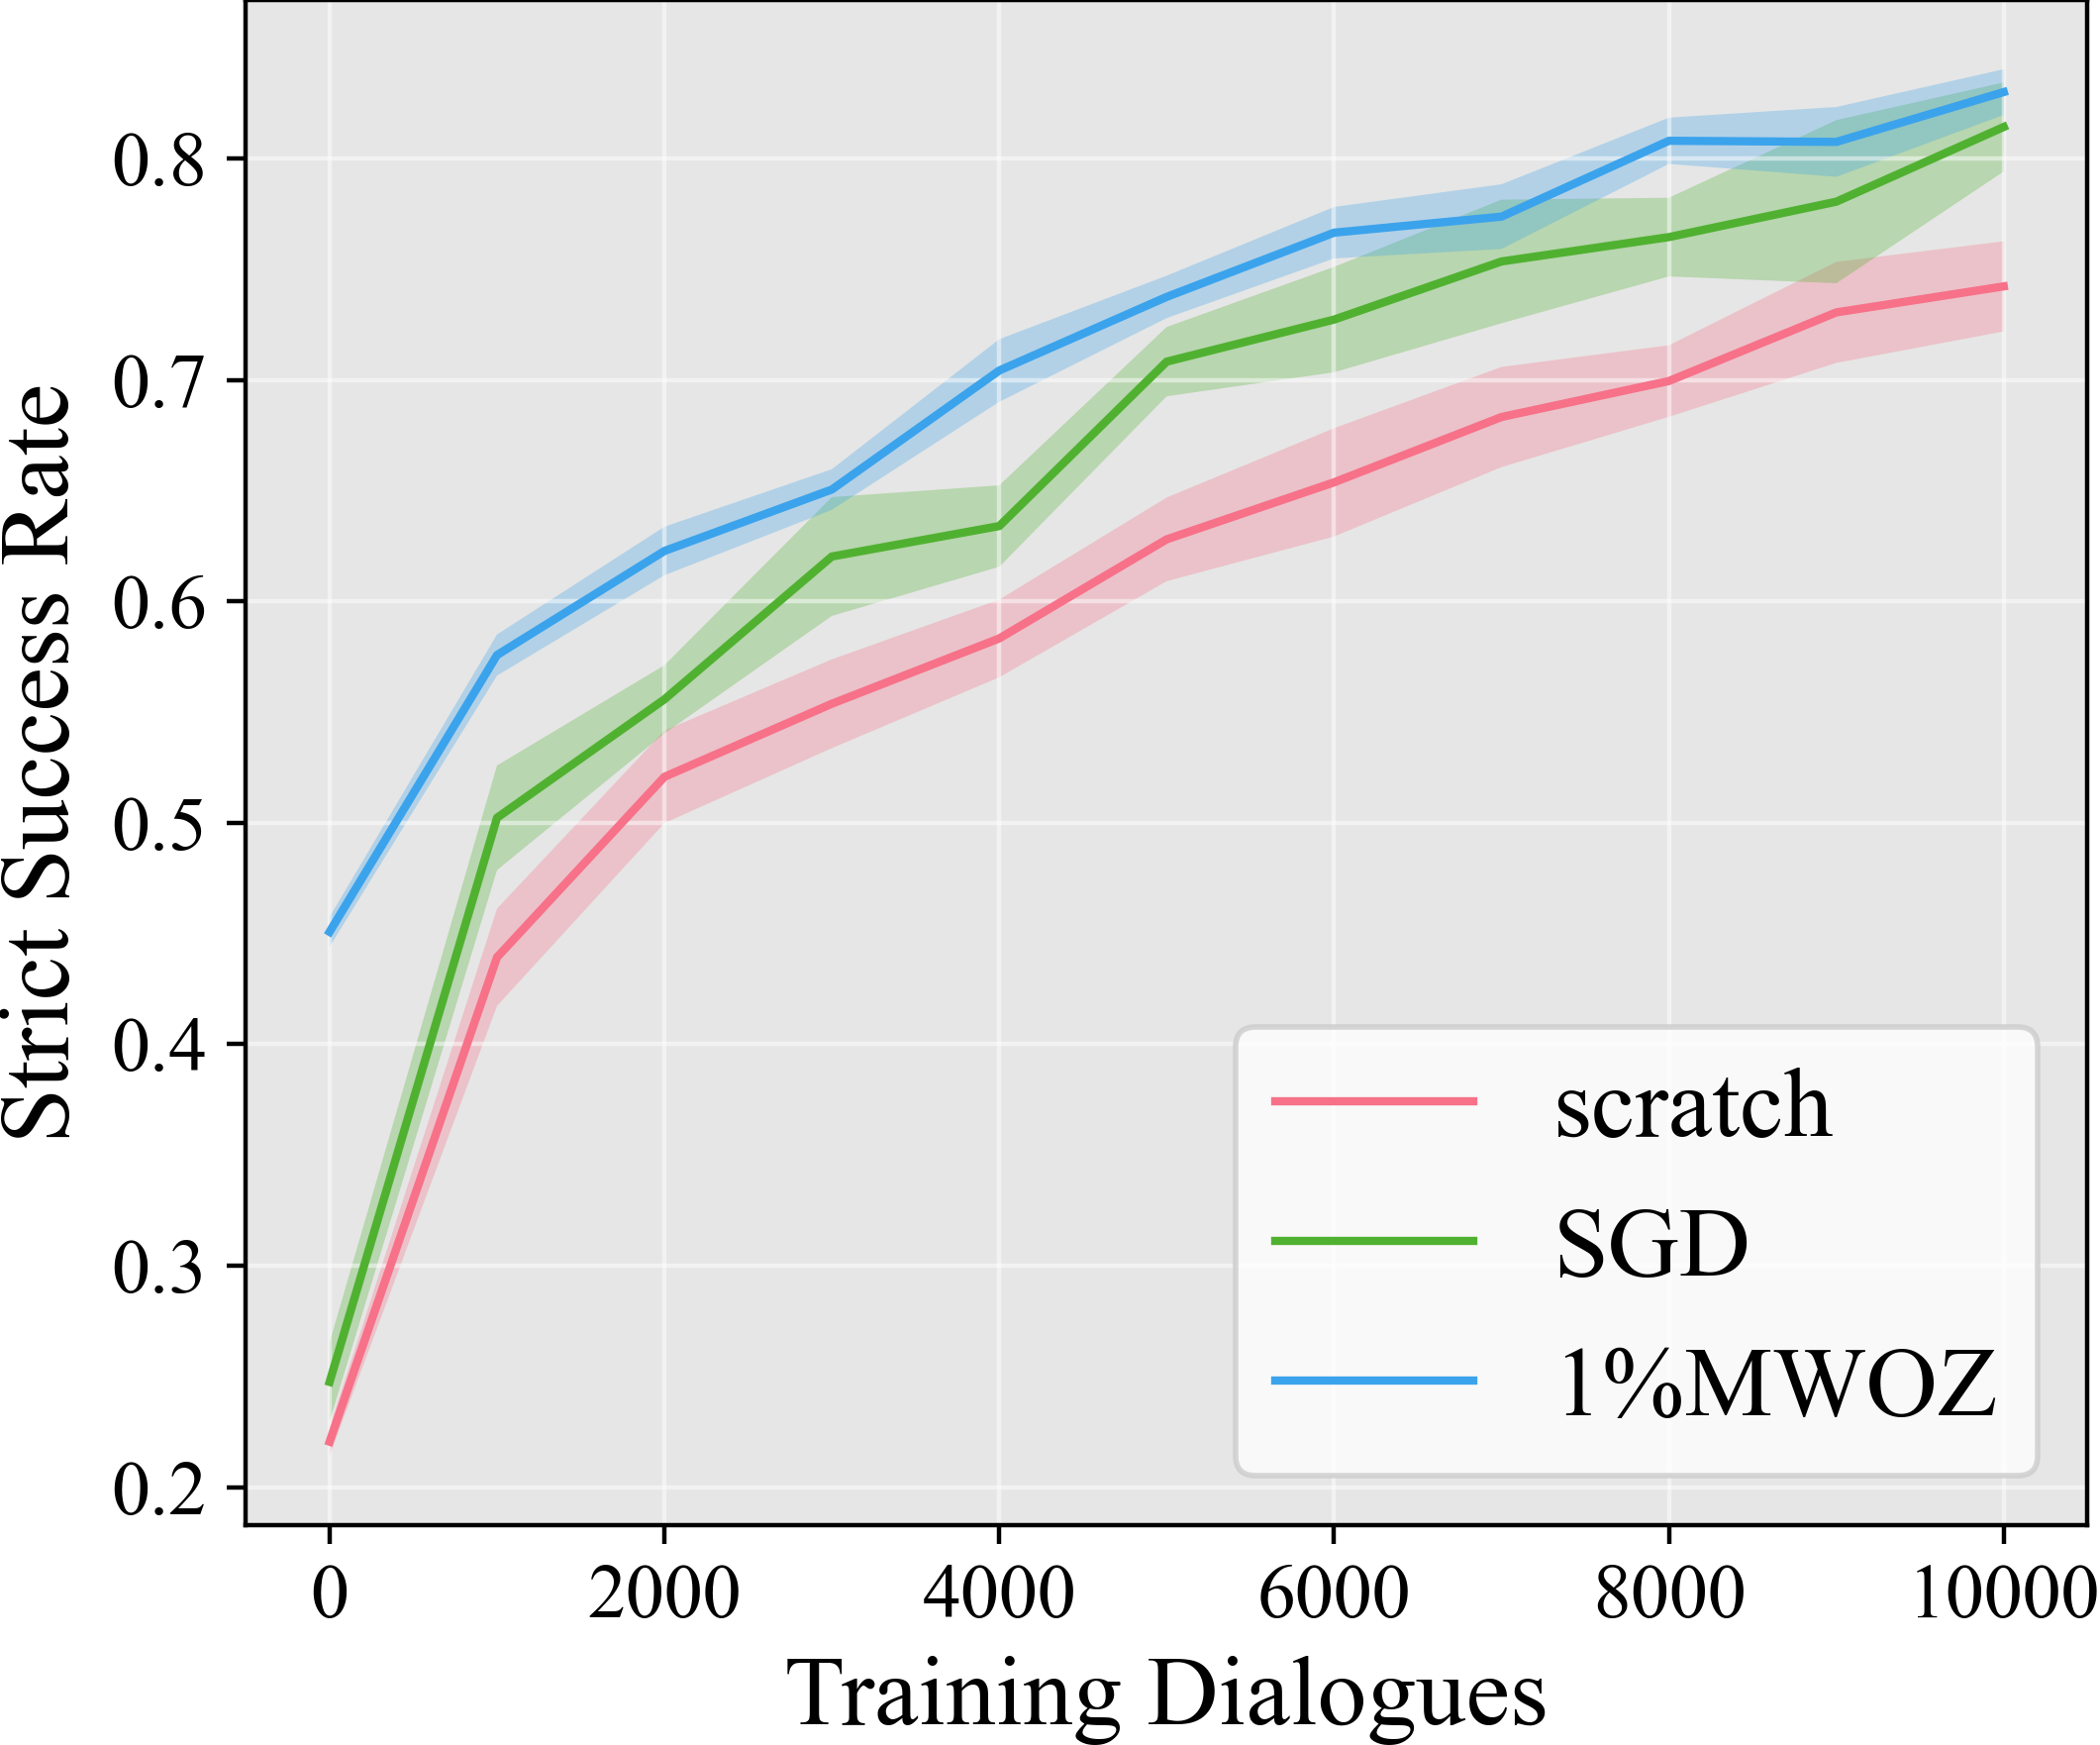

In [19]:
display(Image(filename='convlab_rl_tutorial/rl_figures/_success_rate_strict.png', height=400, width=500))

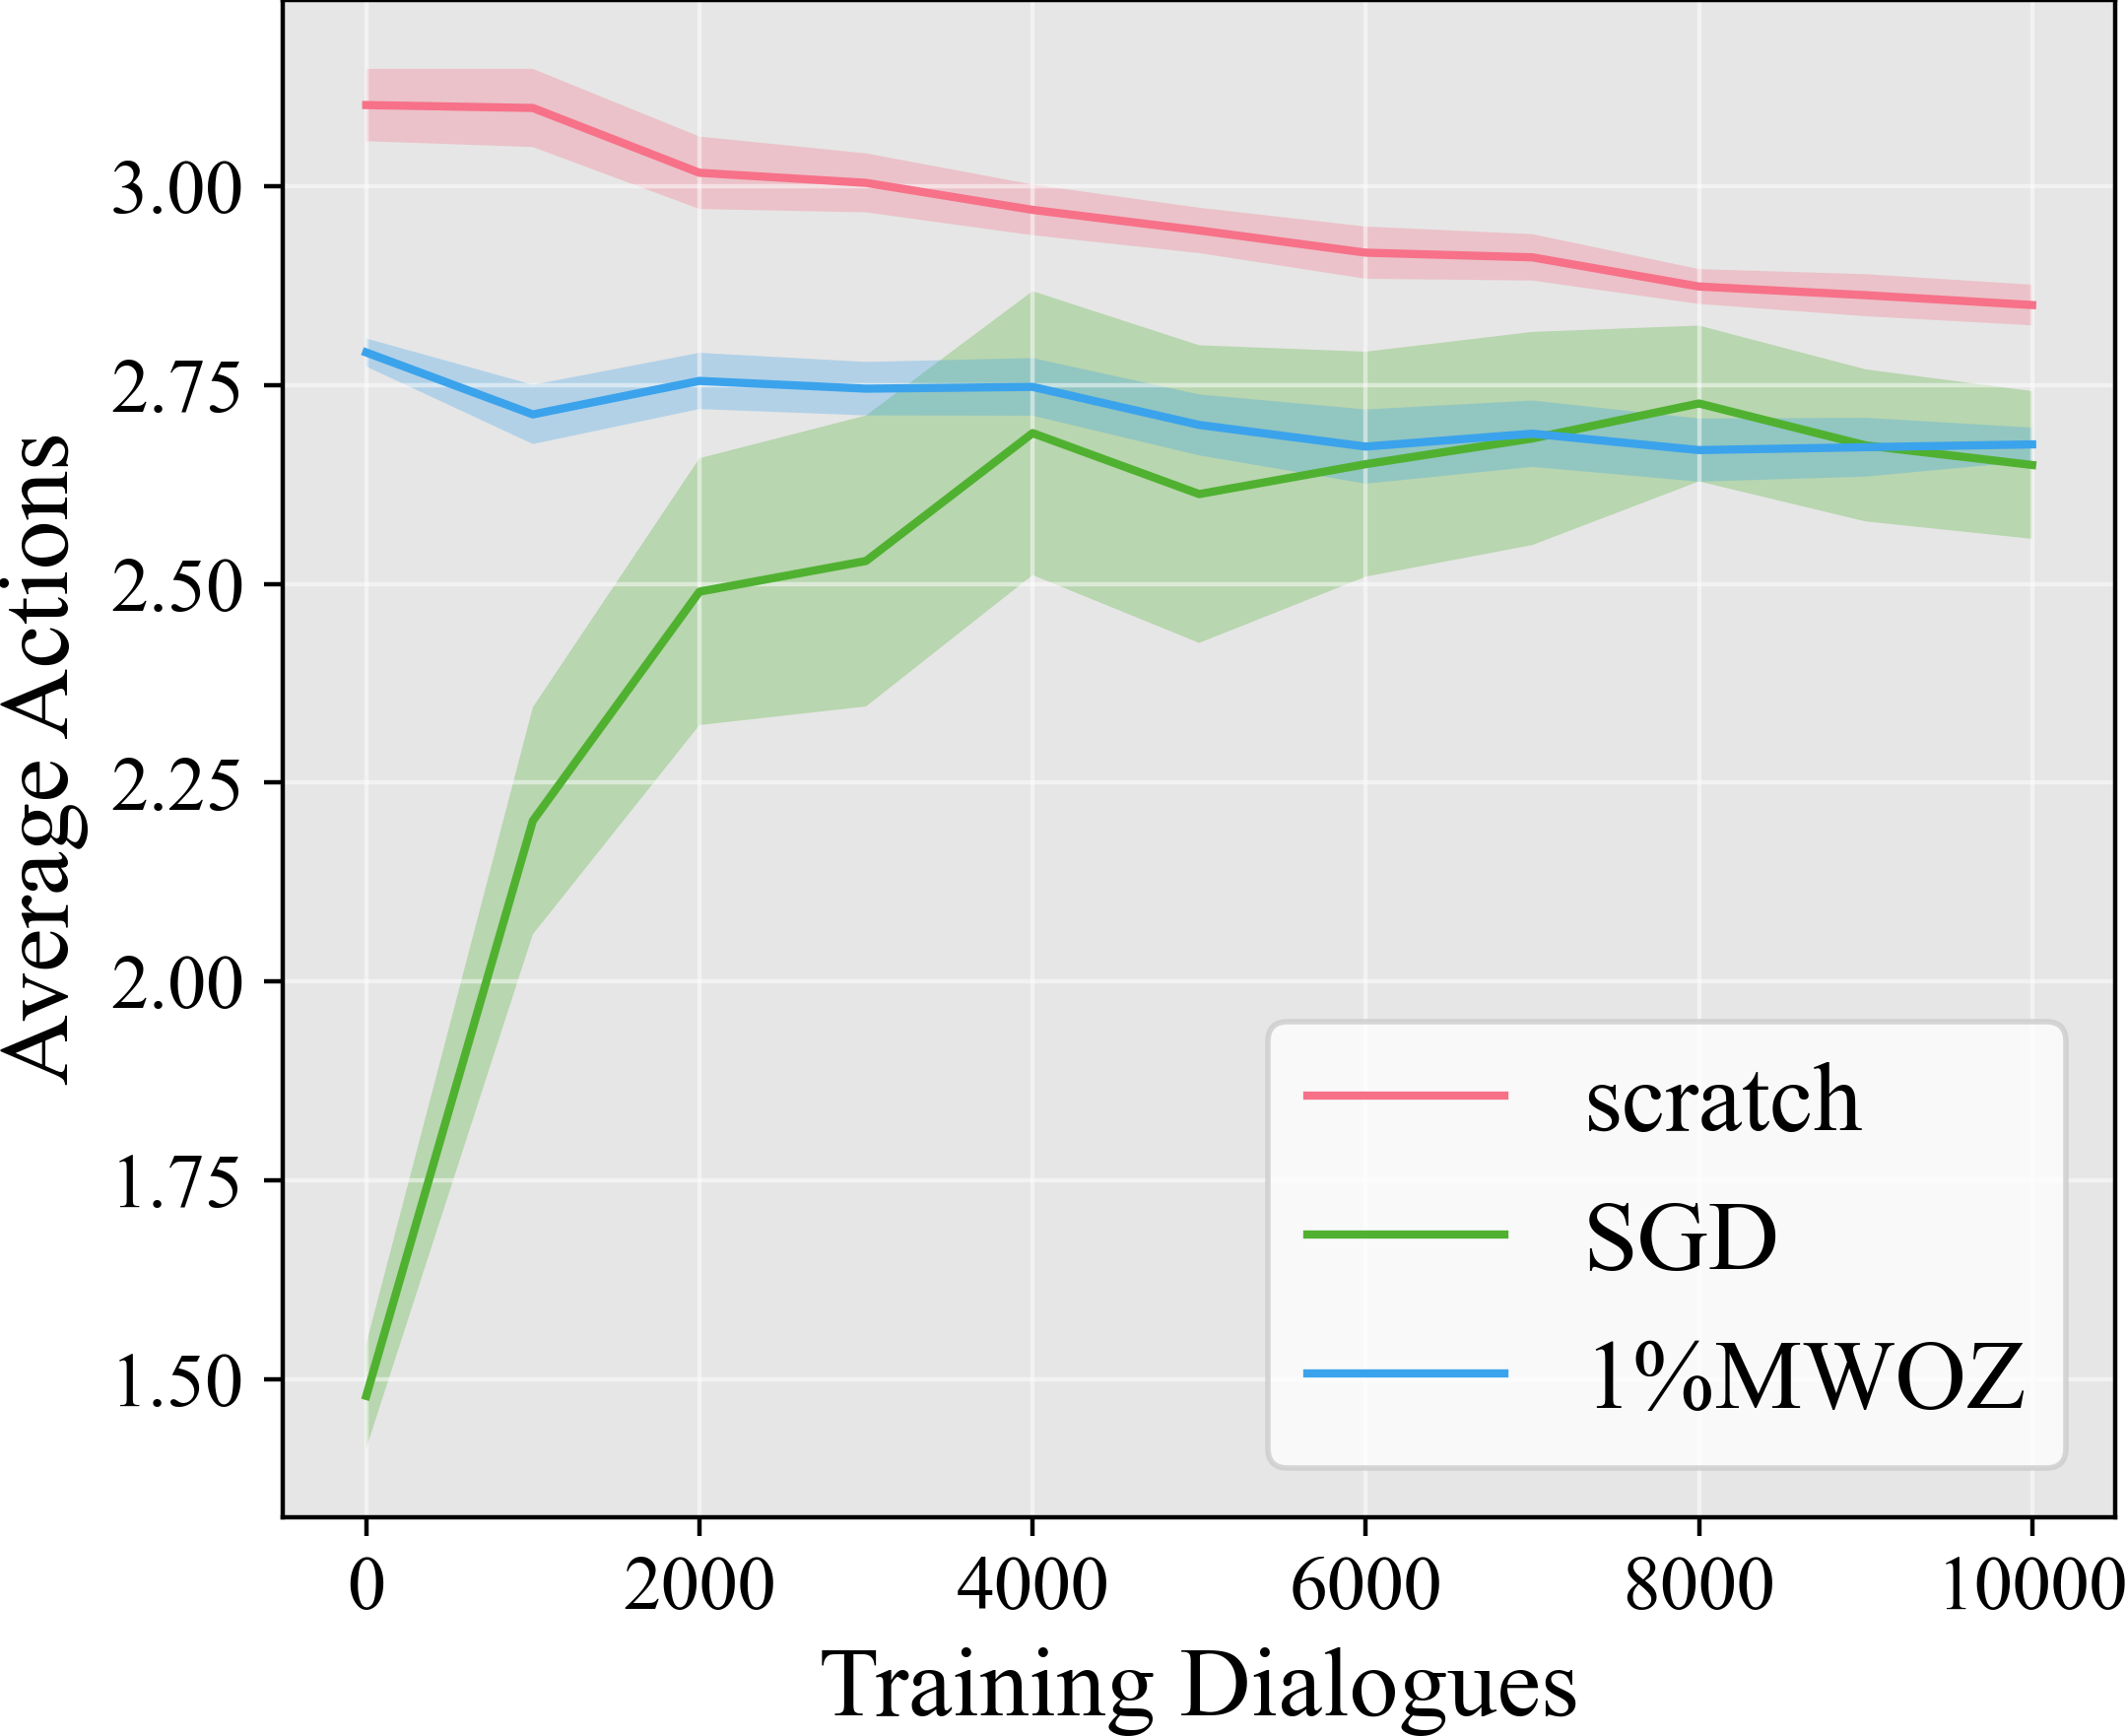

In [21]:
display(Image(filename='convlab_rl_tutorial/rl_figures/_avg_actions.png', height=400, width=500))

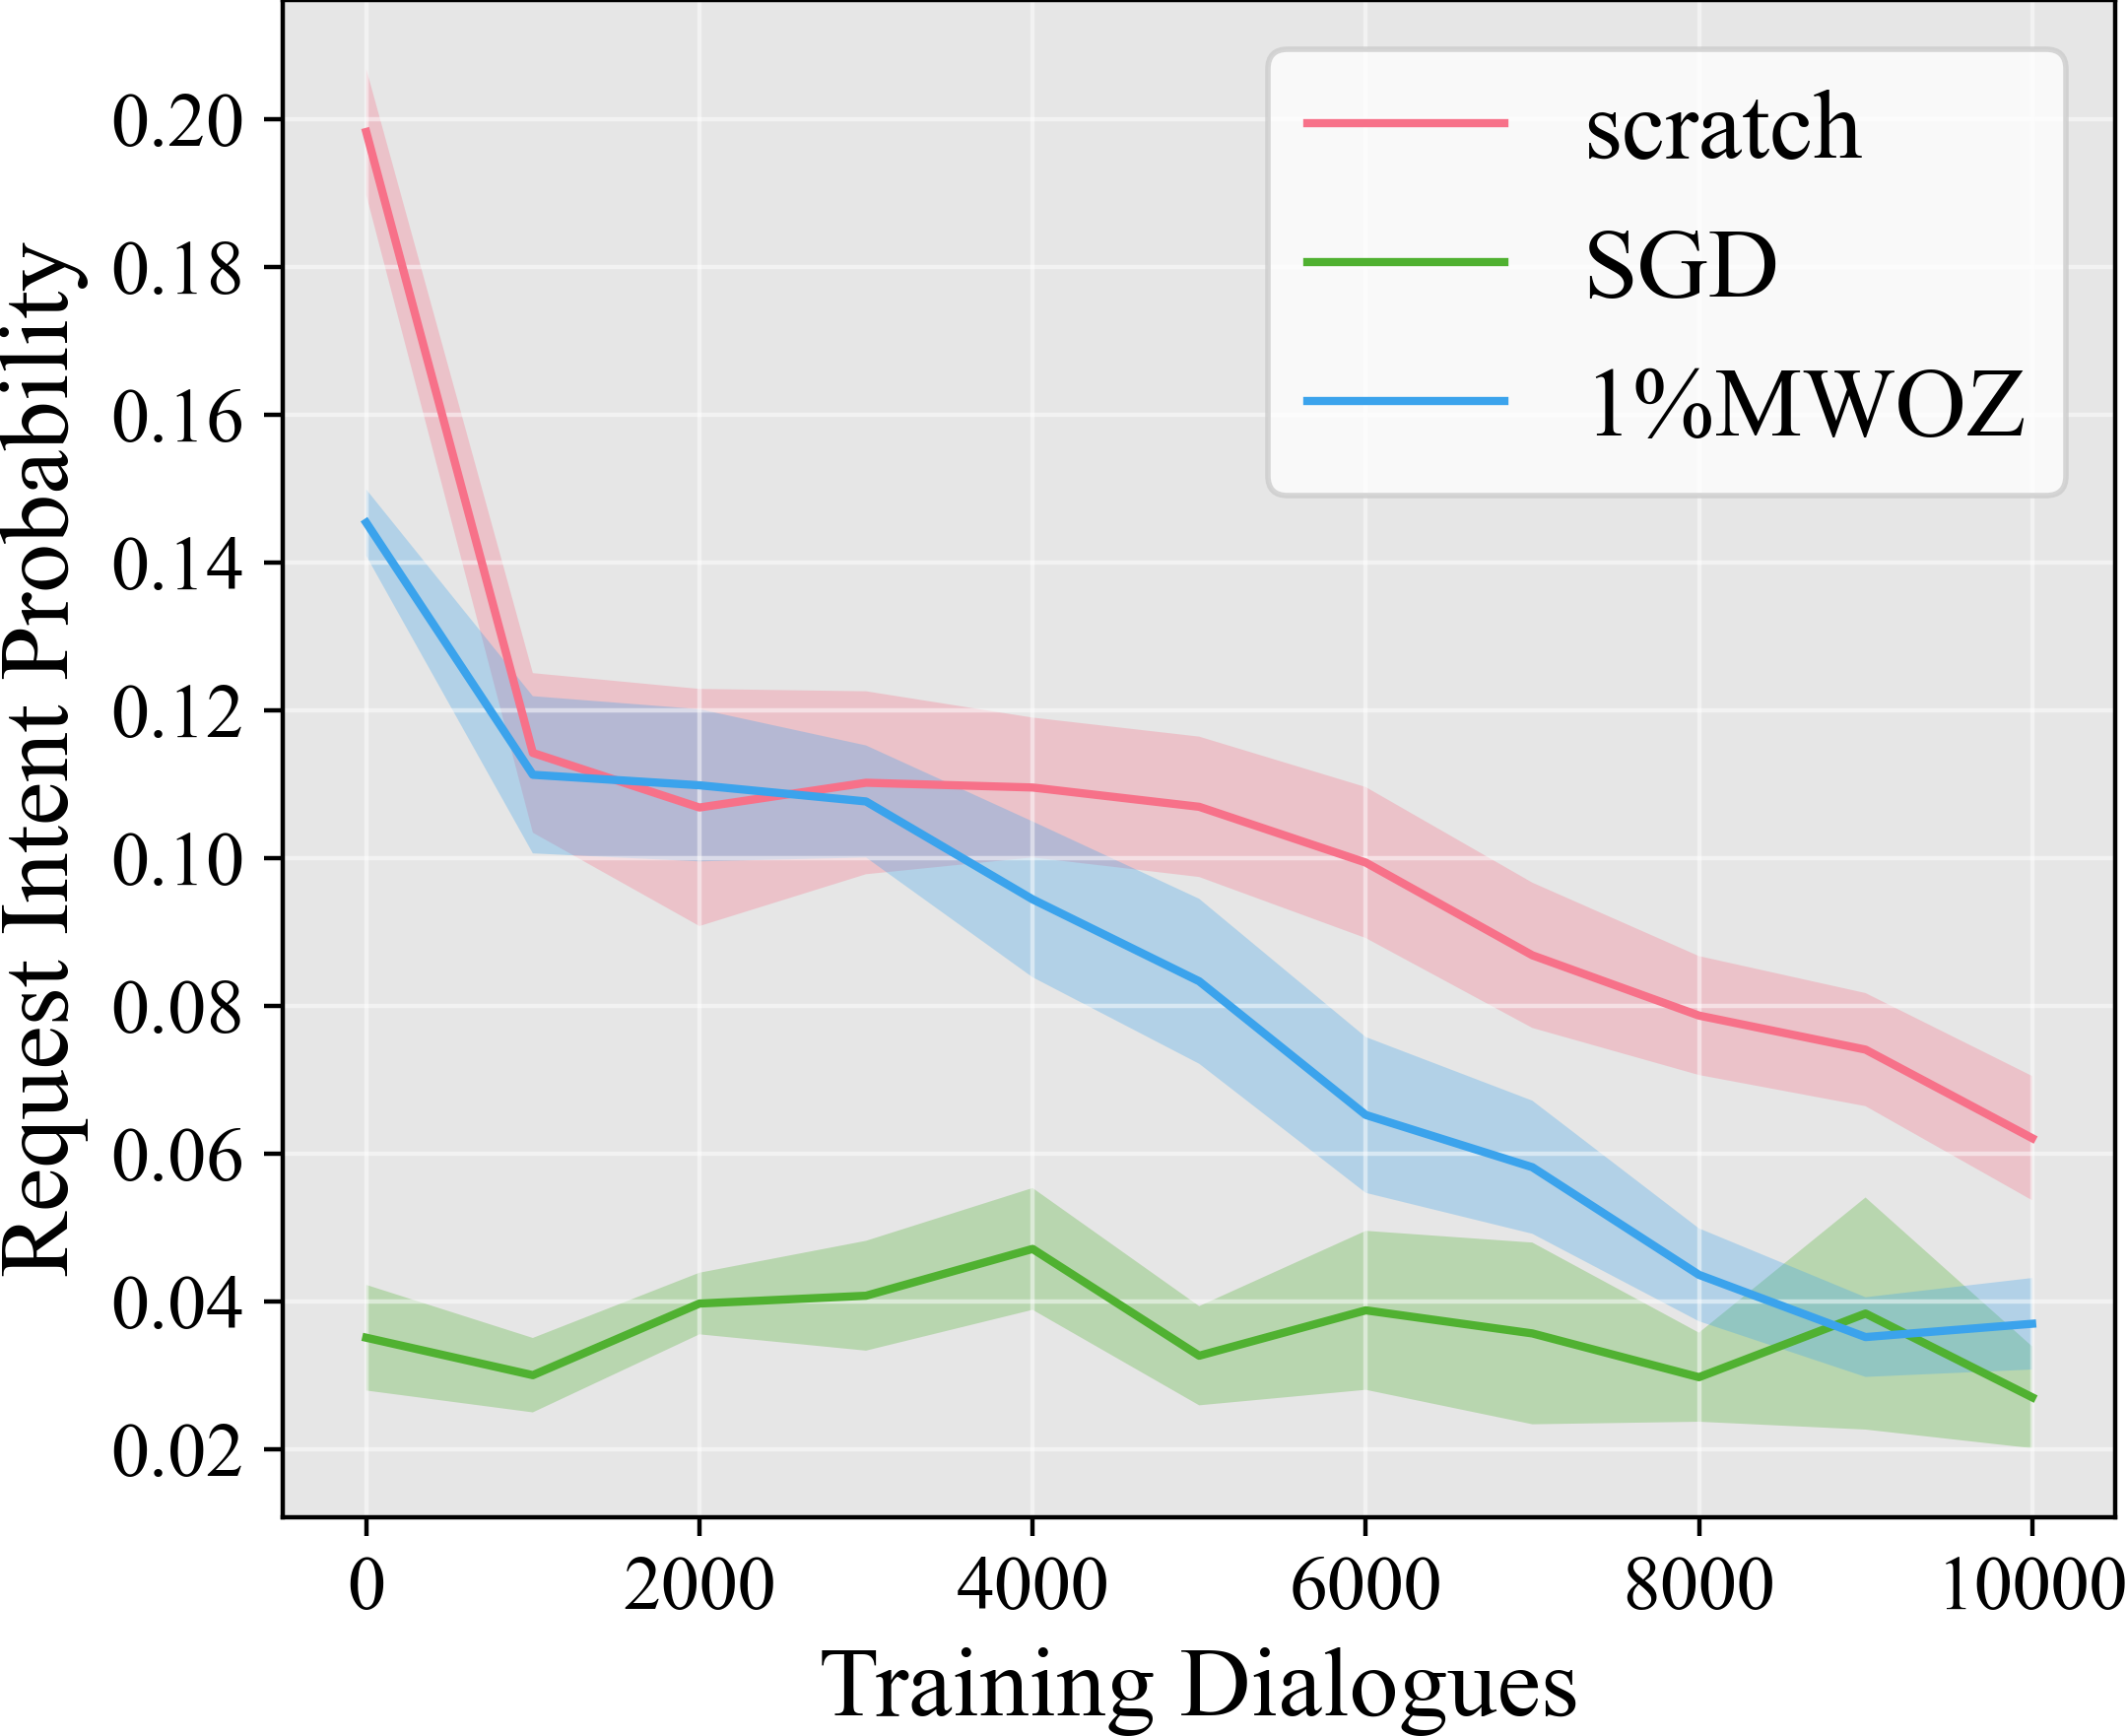

In [22]:
display(Image(filename='convlab_rl_tutorial/rl_figures/request_probability.png', height=400, width=500))